# Paleo erosion calculations
calculating 10-Be concentrations for CT-Ter-2 and 10 samples
&
calculating the history of erosoin in the basin using the equations outlined in text. 
Plot time vs erosion rates over the period of the coastal outcrop

In [1]:
import numpy as np
import matplotlib 
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

In [2]:
"""Calculating the 10-Be lost over time for the two erosion rate samples from the coastal outcrop"""

# Decay constant for 10Be (yr^-1)
lambda_Be10 = 4.997e-7

# Sample data with uncertainties
samples = {
    'CT-Ter-2': {
        'N_measured': 5.10e4,      # atoms/g (measured today)
        'N_uncertainty': 9.67e2,   # atoms/g (1-sigma)
        't_burial': 1.30e6,         # years (burial time)
        't_uncertainty': 0.06e6    # years (1-sigma)
    },
    'CT-Ter-10': {
        'N_measured': 1.20e5,      # atoms/g (measured today)
        'N_uncertainty': 2.25e3,   # atoms/g (1-sigma)
        't_burial': 0.4e6,         # years (burial time)
        't_uncertainty': 0.1e6    # years (1-sigma)
    }
}

# Calculate decay-corrected paleo concentrations with uncertainties
print("="*70)
print("10Be Paleo Concentration Decay Correction with Uncertainties")
print("="*70)
print(f"Decay constant (λ): {lambda_Be10:.3e} yr^-1")
print(f"Half-life: {np.log(2)/lambda_Be10/1e6:.3f} Myr\n")

for sample_name, data in samples.items():
    N_measured = data['N_measured']
    N_uncertainty = data['N_uncertainty']
    t_burial = data['t_burial']
    t_uncertainty = data['t_uncertainty']
    
    # Apply decay correction: N0 = N(t) * exp(λ * t)
    exp_factor = np.exp(lambda_Be10 * t_burial)
    N_paleo = N_measured * exp_factor
    
    # Error propagation for N0 = N(t) * exp(λ * t)
    # Relative uncertainty: σ(N0)/N0 = sqrt[(σ(N)/N)^2 + (λ * σ(t))^2]
    rel_unc_N = N_uncertainty / N_measured
    rel_unc_t = lambda_Be10 * t_uncertainty
    rel_unc_total = np.sqrt(rel_unc_N**2 + rel_unc_t**2)
    
    N_paleo_uncertainty = N_paleo * rel_unc_total
    
    # Calculate contributions
    percent_increase = ((N_paleo - N_measured) / N_measured) * 100
    
    print(f"{sample_name}:")
    print(f"  Measured concentration: {N_measured:.2e} ± {N_uncertainty:.2e} atoms/g")
    print(f"  Burial time: {t_burial/1e6:.2f} ± {t_uncertainty/1e6:.2f} Ma")
    print(f"  Correction factor: {exp_factor:.4f}")
    print(f"  Concentration increase: {percent_increase:.1f}%")
    print(f"")
    print(f"  PALEO CONCENTRATION (N₀):")
    print(f"    {N_paleo:.2e} ± {N_paleo_uncertainty:.2e} atoms/g")
    print(f"")
    print(f"  Uncertainty breakdown:")
    print(f"    Analytical (σ(N)/N): {rel_unc_N*100:.2f}%")
    print(f"    Age (λ·σ(t)): {rel_unc_t*100:.2f}%")
    print(f"    Total relative: {rel_unc_total*100:.2f}%")
    print(f"")
    print(f"  → Input to CRONUS: {N_paleo:.2e} ± {N_paleo_uncertainty:.2e} atoms/g")
    print(f"")
    print("-"*70)
    print()

print("="*70)

10Be Paleo Concentration Decay Correction with Uncertainties
Decay constant (λ): 4.997e-07 yr^-1
Half-life: 1.387 Myr

CT-Ter-2:
  Measured concentration: 5.10e+04 ± 9.67e+02 atoms/g
  Burial time: 1.30 ± 0.06 Ma
  Correction factor: 1.9148
  Concentration increase: 91.5%

  PALEO CONCENTRATION (N₀):
    9.77e+04 ± 3.46e+03 atoms/g

  Uncertainty breakdown:
    Analytical (σ(N)/N): 1.90%
    Age (λ·σ(t)): 3.00%
    Total relative: 3.55%

  → Input to CRONUS: 9.77e+04 ± 3.46e+03 atoms/g

----------------------------------------------------------------------

CT-Ter-10:
  Measured concentration: 1.20e+05 ± 2.25e+03 atoms/g
  Burial time: 0.40 ± 0.10 Ma
  Correction factor: 1.2213
  Concentration increase: 22.1%

  PALEO CONCENTRATION (N₀):
    1.47e+05 ± 7.82e+03 atoms/g

  Uncertainty breakdown:
    Analytical (σ(N)/N): 1.88%
    Age (λ·σ(t)): 5.00%
    Total relative: 5.34%

  → Input to CRONUS: 1.47e+05 ± 7.82e+03 atoms/g

--------------------------------------------------------------

# Calculate the erosion rates over time using qtz and zr fertility calculations

In [3]:
# Calculating paleo-erosion

# File path
excel_file = '/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/MataquitoSampleData.xlsx'

# Sample names
sample_a_name = 'CT-8'
sample_b_name = 'CT-3'
sample_c_name = 'CT-9'

# Paleo erosion rates from CRONUS (m/Myr)
E_c_Ter2_mean = 78.7
E_c_Ter2_std  = 2.8
E_c_Ter10_mean = 51.8
E_c_Ter10_std  = 2.77

# Modern quartz fertility Q_A/Q_B (CT-8/CT-3)
Q_median = 0.0295
Q_q1     = 0.0227
Q_q3     = 0.0375

# Modern zircon fertility Z_A/Z_B (CT-8/CT-3)
Z_median = 0.1682
Z_q1     = 0.1175
Z_q3     = 0.2598

# Paleo mixing weights from U-Pb unmixing
# CT-Ter-2 mixture = CT-8 (0.683) + CT-3 (0.317)
w_z1_Ter2 = 0.683  # weight for A (CT-8)
w_z2_Ter2 = 0.317  # weight for B (CT-3)

# CT-Ter-10 mixture = CT-8 (0.655) + CT-3 (0.345)
w_z1_Ter10 = 0.655
w_z2_Ter10 = 0.345

# Monte Carlo parameters
num_samples = 100000
random_seed = 17
np.random.seed(random_seed)

In [4]:
# Load data
df = pd.read_excel(excel_file)

# Get watershed areas and production rates
A_A = df[df['Sample_ID'] == sample_a_name]['Source_Area'].values[0]
A_B = df[df['Sample_ID'] == sample_b_name]['Source_Area'].values[0]
P_A = df[df['Sample_ID'] == sample_a_name]['Surface_Production_Rate'].values[0]
P_B = df[df['Sample_ID'] == sample_b_name]['Surface_Production_Rate'].values[0]
P_C = df[df['Sample_ID'] == sample_c_name]['Surface_Production_Rate'].values[0]

# Create fertility distributions
Q_mu = np.log(Q_median)
Q_sig = (np.log(Q_q3) - np.log(Q_q1)) / 1.349
Q_samples = np.random.lognormal(mean=Q_mu, sigma=Q_sig, size=num_samples)

Z_mu = np.log(Z_median)
Z_sig = (np.log(Z_q3) - np.log(Z_q1)) / 1.349
Z_samples = np.random.lognormal(mean=Z_mu, sigma=Z_sig, size=num_samples)

def solve_paleo(E_c_mean, E_c_std, w_z1, w_z2, sample_name):
    """Solve for paleo E_A and E_B"""
    
    # Sample E_c from normal distribution
    E_c = np.random.normal(E_c_mean, E_c_std, size=num_samples)
    
    # Resample fertilities
    Q_ratio = np.random.choice(Q_samples, size=num_samples, replace=True)
    Z_ratio = np.random.choice(Z_samples, size=num_samples, replace=True)
    
    E_A_solutions = np.zeros(num_samples)
    E_B_solutions = np.zeros(num_samples)
    
    for i in range(num_samples):
        # From zircon: E_B = k * E_A
        k = Z_ratio[i] * (w_z2 / w_z1) * (A_A / A_B)
        
        # Solve for E_A
        numerator = E_c[i] * (A_B * P_B + Q_ratio[i] * A_A * P_A)
        denominator = P_C * (Q_ratio[i] * A_A + A_B * k)
        
        if denominator > 0 and numerator > 0:
            E_A_solutions[i] = numerator / denominator
            E_B_solutions[i] = k * E_A_solutions[i]
        else:
            E_A_solutions[i] = np.nan
            E_B_solutions[i] = np.nan

    # Print equation with values from first solution
    i = 0
    k = Z_ratio[i] * (w_z2 / w_z1) * (A_A / A_B)
    numerator = E_c[i] * (A_B * P_B + Q_ratio[i] * A_A * P_A)
    denominator = P_C * (Q_ratio[i] * A_A + A_B * k)
    
    print(f"k = {Z_ratio[i]:.4f} * ({w_z2}/{w_z1}) * ({A_A}/{A_B}) = {k:.4f}")
    print(f"E_A = {E_c[i]:.4f} * ({A_B}*{P_B} + {Q_ratio[i]:.4f}*{A_A}*{P_A}) / ({P_C}*({Q_ratio[i]:.4f}*{A_A} + {A_B}*{k:.4f}))")
    print(f"E_A = {numerator:.4f} / {denominator:.4f} = {E_A_solutions[0]:.4f}\n")
    
    # Filter valid solutions
    valid = (E_A_solutions > 0) & (E_B_solutions > 0) & ~np.isnan(E_A_solutions)
    E_A_valid = E_A_solutions[valid]
    E_B_valid = E_B_solutions[valid]
    
    # Calculate statistics
    print(f"\n{sample_name}:")
    print(f"  E_A ({sample_a_name}): {np.median(E_A_valid):.2f} ({np.percentile(E_A_valid, 25):.2f}-{np.percentile(E_A_valid, 75):.2f}) m/Myr")
    print(f"  E_B ({sample_b_name}): {np.median(E_B_valid):.2f} ({np.percentile(E_B_valid, 25):.2f}-{np.percentile(E_B_valid, 75):.2f}) m/Myr")
    print(f"  Valid solutions: {len(E_A_valid)}/{num_samples} ({100*len(E_A_valid)/num_samples:.1f}%)")
    
    return {
        'E_A_median': np.median(E_A_valid),
        'E_B_median': np.median(E_B_valid),
        'E_A_percentiles': (np.percentile(E_A_valid, 25), np.percentile(E_A_valid, 75)),
        'E_B_percentiles': (np.percentile(E_B_valid, 25), np.percentile(E_B_valid, 75)),
        'E_A_samples': E_A_valid,
        'E_B_samples': E_B_valid
    }

# Run solver
print("PALEO EROSION RATES")

results_Ter2 = solve_paleo(E_c_Ter2_mean, E_c_Ter2_std, w_z1_Ter2, w_z2_Ter2, 'CT-Ter-2')
results_Ter10 = solve_paleo(E_c_Ter10_mean, E_c_Ter10_std, w_z1_Ter10, w_z2_Ter10, 'CT-Ter-10')

PALEO EROSION RATES
k = 0.4127 * (0.317/0.683) * (4950.395/189.205) = 5.0111
E_A = 76.1709 * (189.205*5.5128125 + 0.0213*4950.395*14.445275) / (12.523875*(0.0213*4950.395 + 189.205*5.0111))
E_A = 195598.3558 / 13196.2797 = 14.8222


CT-Ter-2:
  E_A (CT-8): 37.51 (27.12-49.75) m/Myr
  E_B (CT-3): 73.39 (63.32-85.51) m/Myr
  Valid solutions: 100000/100000 (100.0%)
k = 0.2270 * (0.345/0.655) * (4950.395/189.205) = 3.1289
E_A = 50.0002 * (189.205*5.5128125 + 0.0309*4950.395*14.445275) / (12.523875*(0.0309*4950.395 + 189.205*3.1289))
E_A = 162565.4933 / 9328.7324 = 17.4263


CT-Ter-10:
  E_A (CT-8): 22.47 (16.10-30.24) m/Myr
  E_B (CT-3): 49.94 (43.07-58.27) m/Myr
  Valid solutions: 100000/100000 (100.0%)


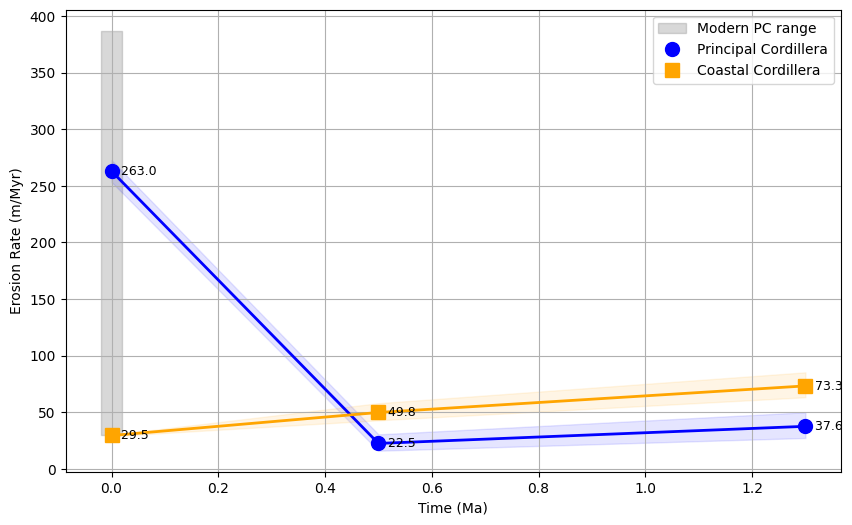

Principal Cordillera (Blue):
Time (Ma) | Median (m/Myr) | Lower bound | Upper bound
------------------------------------------------------------
    1.30 |           37.6 |        27.3 |        50.0
    0.50 |           22.5 |        16.0 |        30.5
    0.00 |          263.0 |       253.3 |       272.6


Coastal Cordillera (Orange):
Time (Ma) | Median (m/Myr) | Lower bound | Upper bound
------------------------------------------------------------
    1.30 |           73.3 |        63.3 |        85.3
    0.50 |           49.8 |        42.9 |        58.0
    0.00 |           29.5 |        28.9 |        30.1


Modern range (Grey bar): 29.8 - 387.0 m/Myr


In [31]:
# Get modern rates and uncertainties
modern_E_A = df[df['Sample_ID'] == sample_a_name]['Erosion_rate'].values[0]
modern_E_A_std = df[df['Sample_ID'] == sample_a_name]['Erosion_rate_uncertainty_internal'].values[0]
modern_E_B = df[df['Sample_ID'] == sample_b_name]['Erosion_rate'].values[0]
modern_E_B_std = df[df['Sample_ID'] == sample_b_name]['Erosion_rate_uncertainty_internal'].values[0]

# Time points
times = [1.30, 0.5, 0.0]

# CT-8 data (Principal Cordillera)
E_A_medians = [results_Ter2['E_A_median'], results_Ter10['E_A_median'], modern_E_A]
E_A_lower = [results_Ter2['E_A_percentiles'][0], results_Ter10['E_A_percentiles'][0], modern_E_A - modern_E_A_std]
E_A_upper = [results_Ter2['E_A_percentiles'][1], results_Ter10['E_A_percentiles'][1], modern_E_A + modern_E_A_std]

# CT-3 data (Coastal Cordillera)
E_B_medians = [results_Ter2['E_B_median'], results_Ter10['E_B_median'], modern_E_B]
E_B_lower = [results_Ter2['E_B_percentiles'][0], results_Ter10['E_B_percentiles'][0], modern_E_B - modern_E_B_std]
E_B_upper = [results_Ter2['E_B_percentiles'][1], results_Ter10['E_B_percentiles'][1], modern_E_B + modern_E_B_std]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Grey vertical bar at modern time (behind everything)
grey_patch = ax.fill_between([-0.02, 0.02], 29.8, 387, color='grey', alpha=0.3, zorder=0, label='Modern PC range')

# Shaded uncertainty envelopes (behind data points)
ax.fill_between(times, E_A_lower, E_A_upper, color='blue', alpha=0.1, zorder=1)
ax.fill_between(times, E_B_lower, E_B_upper, color='orange', alpha=0.1, zorder=1)

# Median lines
ax.plot(times, E_A_medians, '-', color='blue', linewidth=2, zorder=2, label='_nolegend_')
ax.plot(times, E_B_medians, '-', color='orange', linewidth=2, zorder=2, label='_nolegend_')

# Data points (on top)
ax.plot(times, E_A_medians, 'o', markersize=10, color='blue', zorder=3, label="Principal Cordillera")
ax.plot(times, E_B_medians, 's', markersize=10, color='orange', zorder=3, label="Coastal Cordillera")

# Add values next to points
offset = 0.01
for i, (t, ea) in enumerate(zip(times, E_A_medians)):
    ax.text(t + offset, ea, f' {ea:.1f}', va='center', ha='left', fontsize=9)
for i, (t, eb) in enumerate(zip(times, E_B_medians)):
    ax.text(t + offset, eb, f' {eb:.1f}', va='center', ha='left', fontsize=9)

ax.set_xlabel('Time (Ma)')
ax.set_ylabel('Erosion Rate (m/Myr)')
ax.legend()
plt.grid(True)
plt.show()

# Print all values
print("Principal Cordillera (Blue):")
print("Time (Ma) | Median (m/Myr) | Lower bound | Upper bound")
print("-" * 60)
for t, med, low, up in zip(times, E_A_medians, E_A_lower, E_A_upper):
    print(f"{t:8.2f} | {med:14.1f} | {low:11.1f} | {up:11.1f}")

print("\n" + "="*60 + "\n")

print("Coastal Cordillera (Orange):")
print("Time (Ma) | Median (m/Myr) | Lower bound | Upper bound")
print("-" * 60)
for t, med, low, up in zip(times, E_B_medians, E_B_lower, E_B_upper):
    print(f"{t:8.2f} | {med:14.1f} | {low:11.1f} | {up:11.1f}")

print("\n" + "="*60 + "\n")

print("Modern range (Grey bar): 29.8 - 387.0 m/Myr")

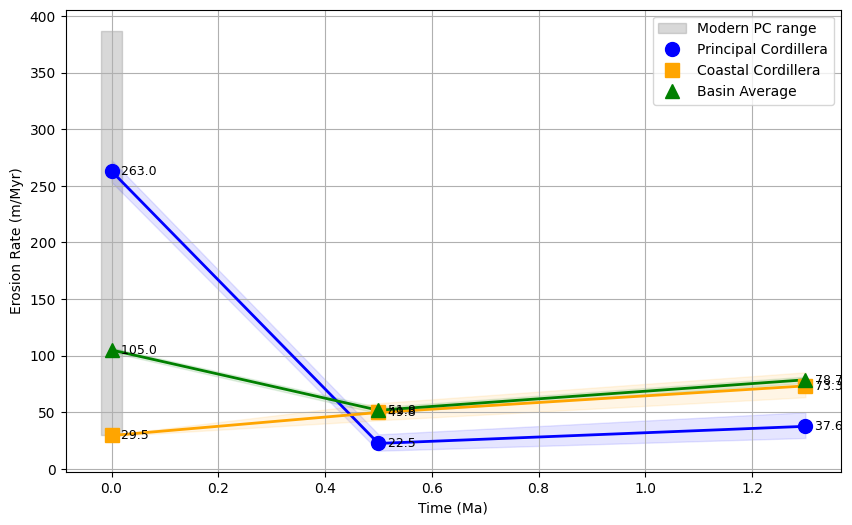

Principal Cordillera (Blue):
Time (Ma) | Median (m/Myr) | Lower bound | Upper bound
------------------------------------------------------------
    1.30 |           37.6 |        27.3 |        50.0
    0.50 |           22.5 |        16.0 |        30.5
    0.00 |          263.0 |       253.3 |       272.6


Coastal Cordillera (Orange):
Time (Ma) | Median (m/Myr) | Lower bound | Upper bound
------------------------------------------------------------
    1.30 |           73.3 |        63.3 |        85.3
    0.50 |           49.8 |        42.9 |        58.0
    0.00 |           29.5 |        28.9 |        30.1


Basin Average (Green):
Time (Ma) | Median (m/Myr) | Lower bound | Upper bound
------------------------------------------------------------
    1.30 |           78.7 |        75.9 |        81.5
    0.50 |           51.8 |        49.0 |        54.6
    0.00 |          105.0 |       103.0 |       107.0


Modern range (Grey bar): 29.8 - 387.0 m/Myr


In [32]:
# Get modern rates and uncertainties
modern_E_A = df[df['Sample_ID'] == sample_a_name]['Erosion_rate'].values[0]
modern_E_A_std = df[df['Sample_ID'] == sample_a_name]['Erosion_rate_uncertainty_internal'].values[0]
modern_E_B = df[df['Sample_ID'] == sample_b_name]['Erosion_rate'].values[0]
modern_E_B_std = df[df['Sample_ID'] == sample_b_name]['Erosion_rate_uncertainty_internal'].values[0]
# Time points
times = [1.30, 0.5, 0.0]
# CT-8 data (Principal Cordillera)
E_A_medians = [results_Ter2['E_A_median'], results_Ter10['E_A_median'], modern_E_A]
E_A_lower = [results_Ter2['E_A_percentiles'][0], results_Ter10['E_A_percentiles'][0], modern_E_A - modern_E_A_std]
E_A_upper = [results_Ter2['E_A_percentiles'][1], results_Ter10['E_A_percentiles'][1], modern_E_A + modern_E_A_std]
# CT-3 data (Coastal Cordillera)
E_B_medians = [results_Ter2['E_B_median'], results_Ter10['E_B_median'], modern_E_B]
E_B_lower = [results_Ter2['E_B_percentiles'][0], results_Ter10['E_B_percentiles'][0], modern_E_B - modern_E_B_std]
E_B_upper = [results_Ter2['E_B_percentiles'][1], results_Ter10['E_B_percentiles'][1], modern_E_B + modern_E_B_std]
# Basin average data
basin_medians = [78.7, 51.8, 105]
basin_lower = [78.7 - 2.8, 51.8 - 2.77, 105 - 2.01]
basin_upper = [78.7 + 2.8, 51.8 + 2.77, 105 + 2.01]
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
# Grey vertical bar at modern time (behind everything)
grey_patch = ax.fill_between([-0.02, 0.02], 29.8, 387, color='grey', alpha=0.3, zorder=0, label='Modern PC range')
# Shaded uncertainty envelopes (behind data points)
ax.fill_between(times, E_A_lower, E_A_upper, color='blue', alpha=0.1, zorder=1)
ax.fill_between(times, E_B_lower, E_B_upper, color='orange', alpha=0.1, zorder=1)
ax.fill_between(times, basin_lower, basin_upper, color='green', alpha=0.1, zorder=1)
# Median lines
ax.plot(times, E_A_medians, '-', color='blue', linewidth=2, zorder=2, label='_nolegend_')
ax.plot(times, E_B_medians, '-', color='orange', linewidth=2, zorder=2, label='_nolegend_')
ax.plot(times, basin_medians, '-', color='green', linewidth=2, zorder=2, label='_nolegend_')
# Data points (on top)
ax.plot(times, E_A_medians, 'o', markersize=10, color='blue', zorder=3, label="Principal Cordillera")
ax.plot(times, E_B_medians, 's', markersize=10, color='orange', zorder=3, label="Coastal Cordillera")
ax.plot(times, basin_medians, '^', markersize=10, color='green', zorder=3, label="Basin Average")
# Add values next to points
offset = 0.01
for i, (t, ea) in enumerate(zip(times, E_A_medians)):
    ax.text(t + offset, ea, f' {ea:.1f}', va='center', ha='left', fontsize=9)
for i, (t, eb) in enumerate(zip(times, E_B_medians)):
    ax.text(t + offset, eb, f' {eb:.1f}', va='center', ha='left', fontsize=9)
for i, (t, bm) in enumerate(zip(times, basin_medians)):
    ax.text(t + offset, bm, f' {bm:.1f}', va='center', ha='left', fontsize=9)
ax.set_xlabel('Time (Ma)')
ax.set_ylabel('Erosion Rate (m/Myr)')
ax.legend()
plt.grid(True)
plt.show()
# Print all values
print("Principal Cordillera (Blue):")
print("Time (Ma) | Median (m/Myr) | Lower bound | Upper bound")
print("-" * 60)
for t, med, low, up in zip(times, E_A_medians, E_A_lower, E_A_upper):
    print(f"{t:8.2f} | {med:14.1f} | {low:11.1f} | {up:11.1f}")
print("\n" + "="*60 + "\n")
print("Coastal Cordillera (Orange):")
print("Time (Ma) | Median (m/Myr) | Lower bound | Upper bound")
print("-" * 60)
for t, med, low, up in zip(times, E_B_medians, E_B_lower, E_B_upper):
    print(f"{t:8.2f} | {med:14.1f} | {low:11.1f} | {up:11.1f}")
print("\n" + "="*60 + "\n")
print("Basin Average (Green):")
print("Time (Ma) | Median (m/Myr) | Lower bound | Upper bound")
print("-" * 60)
for t, med, low, up in zip(times, basin_medians, basin_lower, basin_upper):
    print(f"{t:8.2f} | {med:14.1f} | {low:11.1f} | {up:11.1f}")
print("\n" + "="*60 + "\n")
print("Modern range (Grey bar): 29.8 - 387.0 m/Myr")

In [38]:
# Save figure 
fig.savefig('paleo_erosoin_vs_time_colored.png')